# Machine Learning Modelling

This notebook focuses on preparing the cleaned fintech review dataset for machine learning modelling, including feature selection, train-test splitting, TF-IDF vectorization, and model training/evaluation.

In [1]:
import sys
sys.path.append('..')

# Import Libraries

import pandas as pd
import numpy as np
import gensim
import gensim.corpora as corpora
import shap
import joblib
import re


# Data splitting
from sklearn.model_selection import train_test_split

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform
from sklearn.feature_extraction.text import (TfidfVectorizer,ENGLISH_STOP_WORDS)
from sklearn.model_selection import (RandomizedSearchCV,StratifiedKFold)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from collections import Counter

from sklearn.preprocessing import LabelEncoder

# Evaluation Metrics

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    accuracy_score
)


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

from src.evaluate import evaluate_model

## Load Final Clean Dataset

In [2]:
# Load cleaned dataset

# Reload safely
cleaned_df = pd.read_csv(
    '../data/cleaned_data.csv',
    keep_default_na=False
)

In [3]:
# Check dataset shape

cleaned_df.shape

(53506, 23)

In [4]:
cleaned_df.isna().sum()

reviewId               0
content                0
score                  0
thumbsUpCount          0
at                     0
appVersion             0
app_name               0
sentiment              0
with_emojis            0
cleaned_text           0
final_language         0
normalized_text        0
tokens                 0
tokens_no_stopwords    0
meaningful_tokens      0
stemmed_tokens         0
lemmatized_tokens      0
processed_text         0
sentiment_label        0
complaint_label        0
fraud_indicator        0
review_length          0
word_count             0
dtype: int64

In [5]:
print(cleaned_df['sentiment_label'].value_counts())
print(cleaned_df['sentiment_label'].value_counts(normalize=True) * 100)

sentiment_label
positive    40296
negative    11040
neutral      2170
Name: count, dtype: int64
sentiment_label
positive    75.31118
negative    20.63320
neutral      4.05562
Name: proportion, dtype: float64


## Feature and Target Variables

In [6]:
# Features and target

X = cleaned_df["processed_text"]

y = cleaned_df["sentiment"]

In [7]:
print(X.head())

0    still issue otp havent received otp login trie...
1    everytime nitakuwa bundle check number try fix...
2                             stupidest ever saf worst
3    life must without useless used work well data ...
4                                     upgrade terrible
Name: processed_text, dtype: str


In [8]:
print(y.head())

0    negative
1    negative
2    negative
3    negative
4    negative
Name: sentiment, dtype: str


## Verify Class Distribution

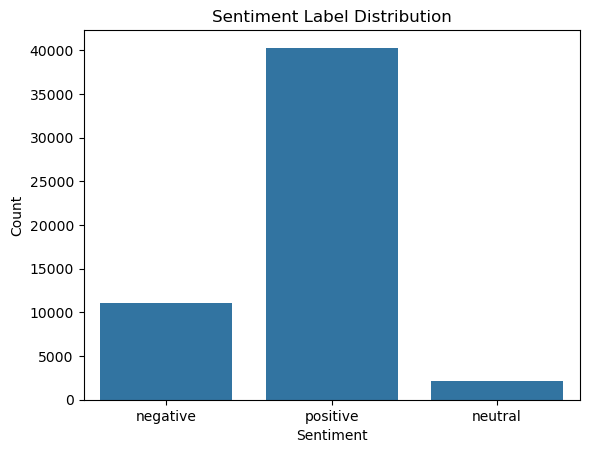

In [9]:
# Plot class distribution

sns.countplot(x=y)

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [10]:
y.unique()

<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str

### Observation

The dataset shows class imbalance, with positive sentiments having the highest number of reviews compared to negative and average sentiments. This imbalance should be considered during model evaluation.

In [11]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])

[0 0 0 0 0 0 0 0 2 0]


## Train-Test Split

### Multilingual Negation Handling

Before train-test split a function to improve sentiment classification by detecting and transforming negative expressions in English, Swahili, and Sheng before vectorization. Common complaint phrases such as *"not working"*, *"hakuna network"*, and *"imekataa"* are replaced with a unified negative token to strengthen negative sentiment detection. The function also joins negation words with nearby terms (e.g., `not good → not_good`) to preserve contextual meaning during TF-IDF feature extraction. This preprocessing step helps reduce false positive predictions and improves multilingual sentiment accuracy.

In [12]:

# Multilingual Negation Handling Function


def handle_negations(text):

    text = str(text).lower()

    
    # English negations
   

    english_patterns = {
        r"\bnot good\b": "negative",
        r"\bnot working\b": "negative",
        r"\bnot helpful\b": "negative",
        r"\bnot useful\b": "negative",
        r"\bnot reliable\b": "negative",
        r"\bnot happy\b": "negative",
        r"\bnot impressed\b": "negative",
        r"\bnot satisfied\b": "negative",
        r"\bno network\b": "negative",
        r"\bno signal\b": "negative",
        r"\bnever works\b": "negative",
        r"\bnever helps\b": "negative",
        r"\bfailed transaction\b": "negative",
        r"\bmoney deducted\b": "negative"
    }

    
    # Swahili / Sheng negations
    

    swahili_patterns = {
        r"\bhaifanyi\b": "negative",
        r"\bhakuna network\b": "negative",
        r"\bhakuna signal\b": "negative",
        r"\bsi nzuri\b": "negative",
        r"\bimekataa\b": "negative",
        r"\bimekwama\b": "negative",
        r"\bmbaya\b": "negative",
        r"\bhovyo\b": "negative",
        r"\bmatata\b": "negative",
        r"\bwizi\b": "negative",
        r"\bscam\b": "negative",
        r"\bfraud\b": "negative",
        r"\bslow sana\b": "negative"
    }

    # Replace strong negative phrases
    for pattern, replacement in english_patterns.items():
        text = re.sub(pattern, replacement, text)

    for pattern, replacement in swahili_patterns.items():
        text = re.sub(pattern, replacement, text)


    # Generic negation joining
    

    text = re.sub(r"\b(not|no|never)\s+(\w+)", r"\1_\2", text)

    # Swahili negation joining
    text = re.sub(r"\b(si|hakuna|hai|ha)\s+(\w+)", r"\1_\2", text)

    return text

In [13]:
# 2. Apply to full dataset
X = X.apply(handle_negations)

In [14]:
# Split dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (42804,)
X_test: (10702,)
y_train: (42804,)
y_test: (10702,)


In [15]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:")
print(Counter(y_train))


Before SMOTE:
Counter({np.int64(2): 32236, np.int64(0): 8832, np.int64(1): 1736})


In [16]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 42804
Testing samples: 10702


#### Modelling Techniques
1. Baseline Model

- TF-IDF + Logistic Regression

A TF-IDF Vectorizer combined with Logistic Regression was used as the baseline NLP model. TF-IDF converted review text into numerical features, while Logistic Regression classified customer sentiment efficiently and provided an interpretable benchmark for evaluating more advanced models

In [17]:
# Baseline Model: TF-IDF + Logistic Regression
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("logreg", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

intermediate_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("xgb", XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
])

Training Baseline Model...
Running Cross-Validation...

=================== Baseline Model Results ===================
 Weighted F1 Score: 0.8279
 Precision: 0.8545
 Recall: 0.8056
 Cross-validation F1 (mean): 0.8253

 Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.72      0.72      2208
           1       0.10      0.24      0.14       434
           2       0.93      0.86      0.89      8060

    accuracy                           0.81     10702
   macro avg       0.59      0.60      0.58     10702
weighted avg       0.85      0.81      0.83     10702

🎉 Model meets target F1 ≥ 0.75



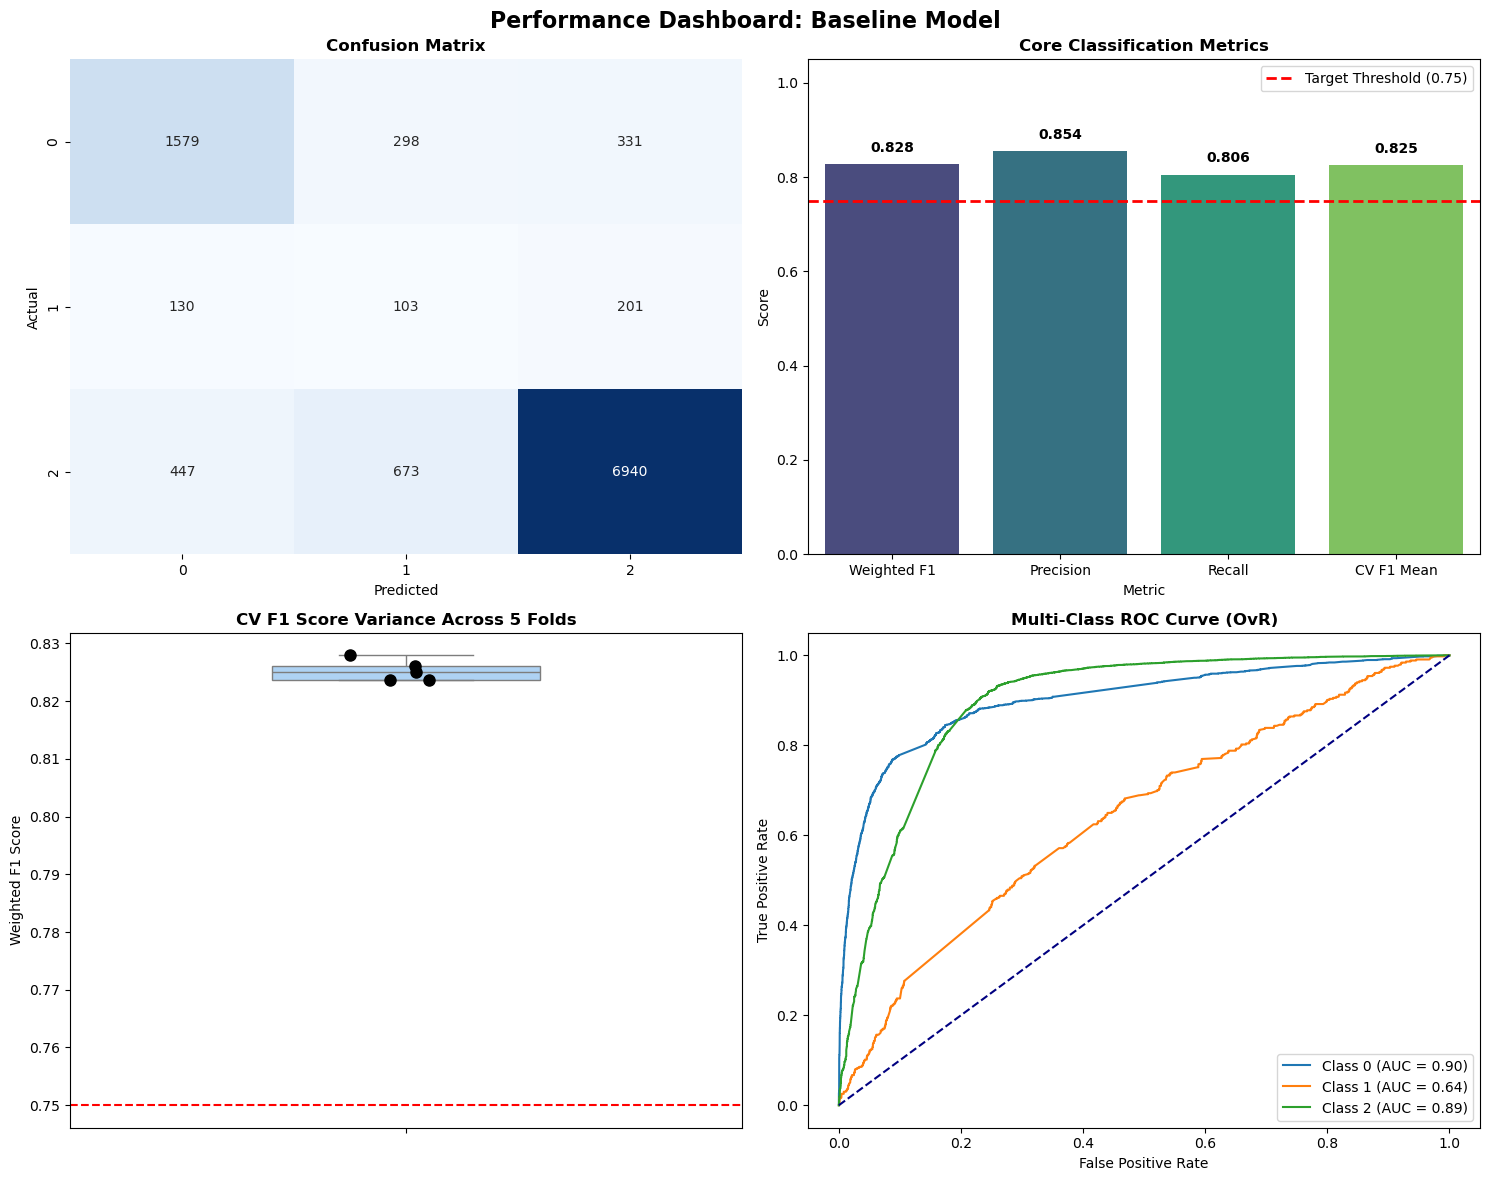

In [18]:
# 4. Evaluate Baseline
baseline_results = evaluate_model(baseline_pipeline, X_train, X_test, y_train, y_test, "Baseline Model")

The baseline TF-IDF + Logistic Regression model achieved a weighted F1-score of 0.8274 and an overall accuracy of 81%, indicating strong general sentiment classification performance. The model performed best on the majority positive class (Class 2) with an F1-score of 0.89, while performance on the minority neutral class (Class 1) remained low due to class imbalance. Cross-validation results (mean F1-score: 0.8255) showed that the model generalized consistently across different data splits, making it a reliable benchmark for evaluating more advanced models.

The confusion matrix shows that the baseline model performed strongly in identifying positive reviews (Class 2), correctly classifying 6,931 instances. The model also achieved moderate performance on negative reviews (Class 0), but struggled to accurately identify neutral reviews (Class 1), which were frequently misclassified as positive. This pattern suggests the presence of class imbalance, where the model favored the majority positive class while underperforming on minority sentiment categories.


Training Intermediate Model...
Running Cross-Validation...

=================== Intermediate Model Results ===================
 Weighted F1 Score: 0.817
 Precision: 0.8099
 Recall: 0.8462
 Cross-validation F1 (mean): 0.8148

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.51      0.63      2208
           1       0.00      0.00      0.00       434
           2       0.85      0.98      0.91      8060

    accuracy                           0.85     10702
   macro avg       0.56      0.50      0.51     10702
weighted avg       0.81      0.85      0.82     10702

🎉 Model meets target F1 ≥ 0.75



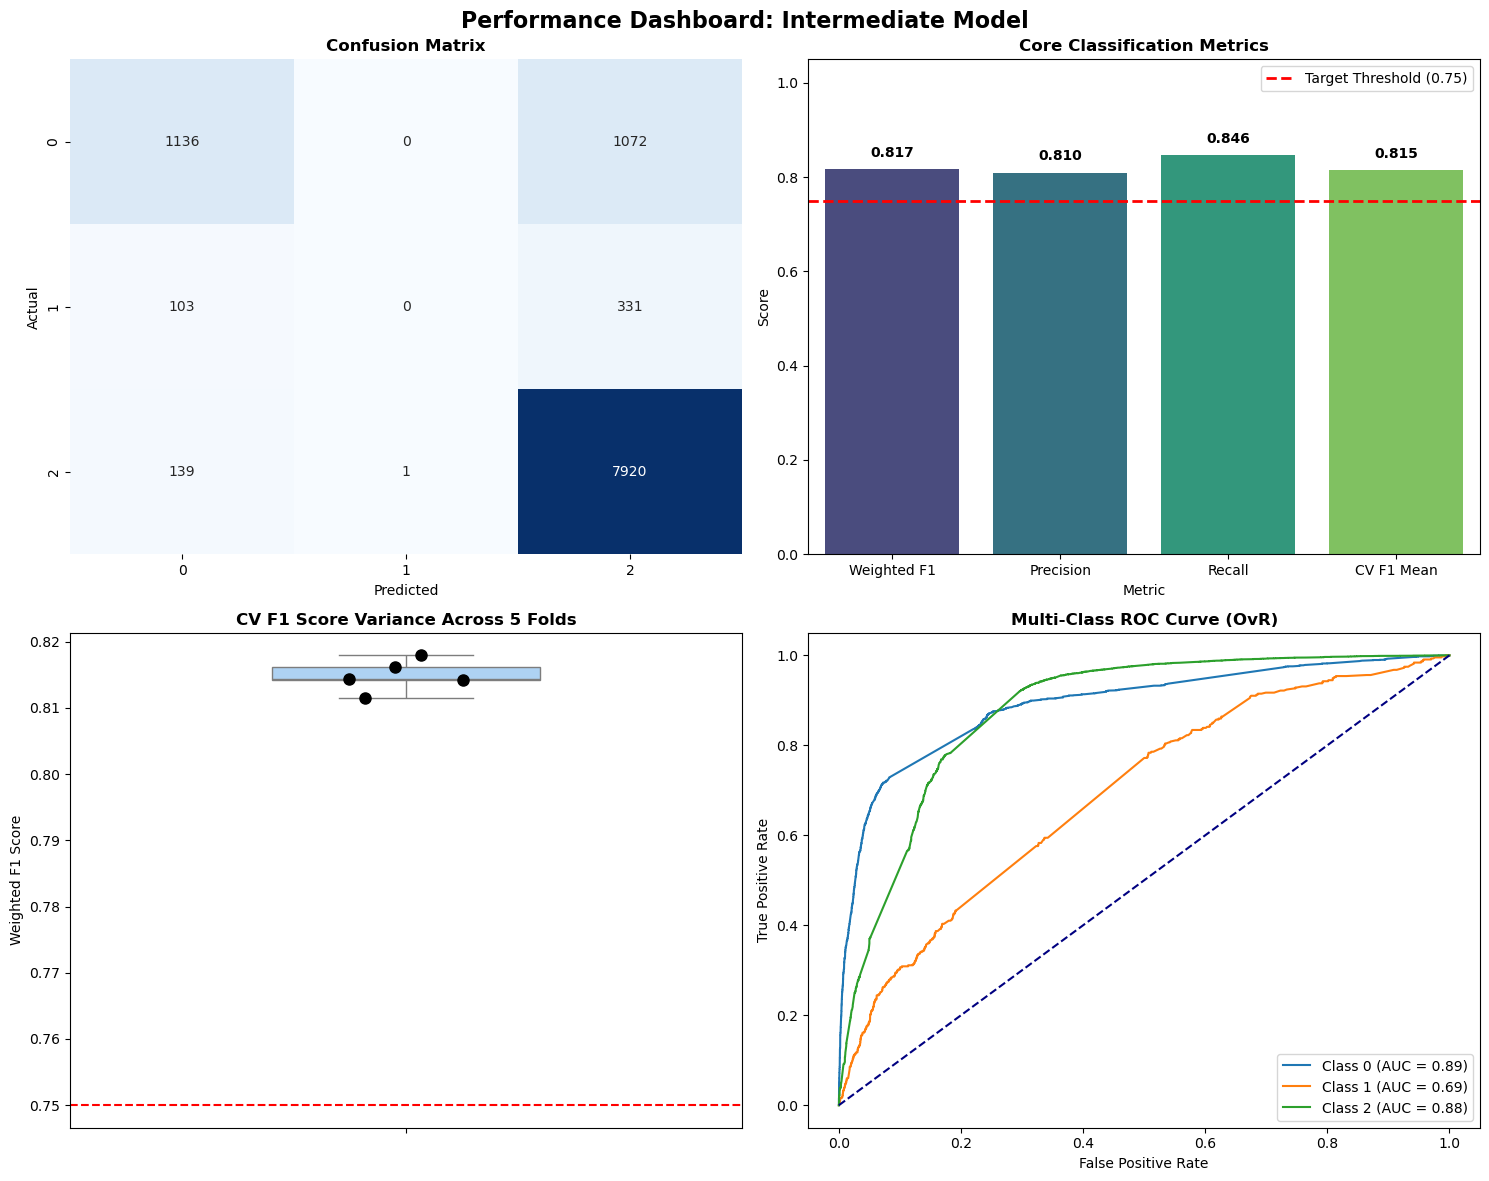

In [19]:
# 5. Evaluate Intermediate
intermediate_results = evaluate_model(intermediate_pipeline, X_train, X_test, y_train, y_test, "Intermediate Model")

The intermediate TF-IDF + XGBoost model achieved an overall accuracy of 85% and a weighted F1-score of 0.818, showing strong performance in predicting the majority positive class (Class 2) with an F1-score of 0.91. The model demonstrated higher recall compared to the baseline model, indicating improved ability to capture positive reviews. However, performance on the neutral class (Class 1) remained poor, with the model failing to correctly classify most neutral reviews due to severe class imbalance. Cross-validation results (mean F1-score: 0.8157) indicated stable and consistent model performance across validation folds.


## Advanced Model: TF-IDF + XGBoost with Hyperparameter Tuning

The advanced model builds upon the intermediate pipeline by:
- **Parameter tuning** via `RandomizedSearchCV` over a broad XGBoost + TF-IDF search space
- **Feature importance** from the fitted XGBoost tree ensemble
- **SHAP explainability** for per-prediction transparency
- **Final comparison** against the Logistic Regression baseline

#### Define the TF-IDF + XGBoost Pipeline

A `Pipeline` is used so that TF-IDF and XGBoost are treated as a single estimator inside `RandomizedSearchCV`, preventing any data leakage between the vectoriser fit and cross-validation folds.

####  Hyperparameter Search Space

The search covers both TF-IDF parameters (vocabulary size, n-gram range) and XGBoost parameters (tree depth, learning rate, regularisation, subsampling).  
`RandomizedSearchCV` samples 30 combinations — a good trade-off between coverage and compute.

### Handling Class Imbalance with SMOTE

To address class imbalance in the training data, the Synthetic Minority Oversampling Technique (SMOTE) is applied after TF-IDF vectorization. SMOTE generates synthetic samples for underrepresented sentiment classes, helping the model learn balanced decision boundaries across positive, neutral, and negative reviews. This improves the classifier’s ability to correctly identify minority class sentiments and reduces prediction bias toward majority classes.

In [ ]:

# Keep negation words in stopword list

custom_stopwords = list(
    ENGLISH_STOP_WORDS.difference([
        "not",
        "no",
        "nor",
        "never"
    ])
)


# TF-IDF Vectorization


tfidf = TfidfVectorizer(
    stop_words=custom_stopwords,
    ngram_range=(1, 2),
    max_features=1000,
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF completed")

# Apply SMOTE


smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_tfidf,
    y_train
)

print("\nClass Distribution After SMOTE:")
print(Counter(y_train_resampled))


# XGBOOST Model

advanced_pipeline = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)


# Hyperparameter space for tuning


param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.08, 0.1],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}


# Cross Validation 


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# Randomized Search CV


search = RandomizedSearchCV(
    estimator=advanced_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_weighted",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    refit=True
)


# Train model with hyperparameter tuning

search.fit(
    X_train_resampled,
    y_train_resampled
)


# Best model from search


best_model = search.best_estimator_

print("\nBest CV F1 (weighted):", round(search.best_score_, 4))

print("\nBest Parameters:")

for k, v in search.best_params_.items():
    print(f"{k}: {v}")


# Predictions


predictions = best_model.predict(X_test_tfidf)

TF-IDF completed

Class Distribution After SMOTE:
Counter({np.int64(0): 32236, np.int64(2): 32236, np.int64(1): 32236})
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CV F1 (weighted): 0.7254

Best Parameters:
subsample: 0.8
n_estimators: 200
max_depth: 8
learning_rate: 0.1
colsample_bytree: 0.8


#### Evaluate the Tuned Advanced Model

Training Advanced XGBoost (Tuned)...
Running Cross-Validation...

=================== Advanced XGBoost (Tuned) Results ===================
 Weighted F1 Score: 0.8401
 Precision: 0.8294
 Recall: 0.8633
 Cross-validation F1 (mean): 0.8415

 Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.63      0.71      2208
           1       0.09      0.00      0.00       434
           2       0.87      0.97      0.92      8060

    accuracy                           0.86     10702
   macro avg       0.59      0.53      0.54     10702
weighted avg       0.83      0.86      0.84     10702

🎉 Model meets target F1 ≥ 0.75



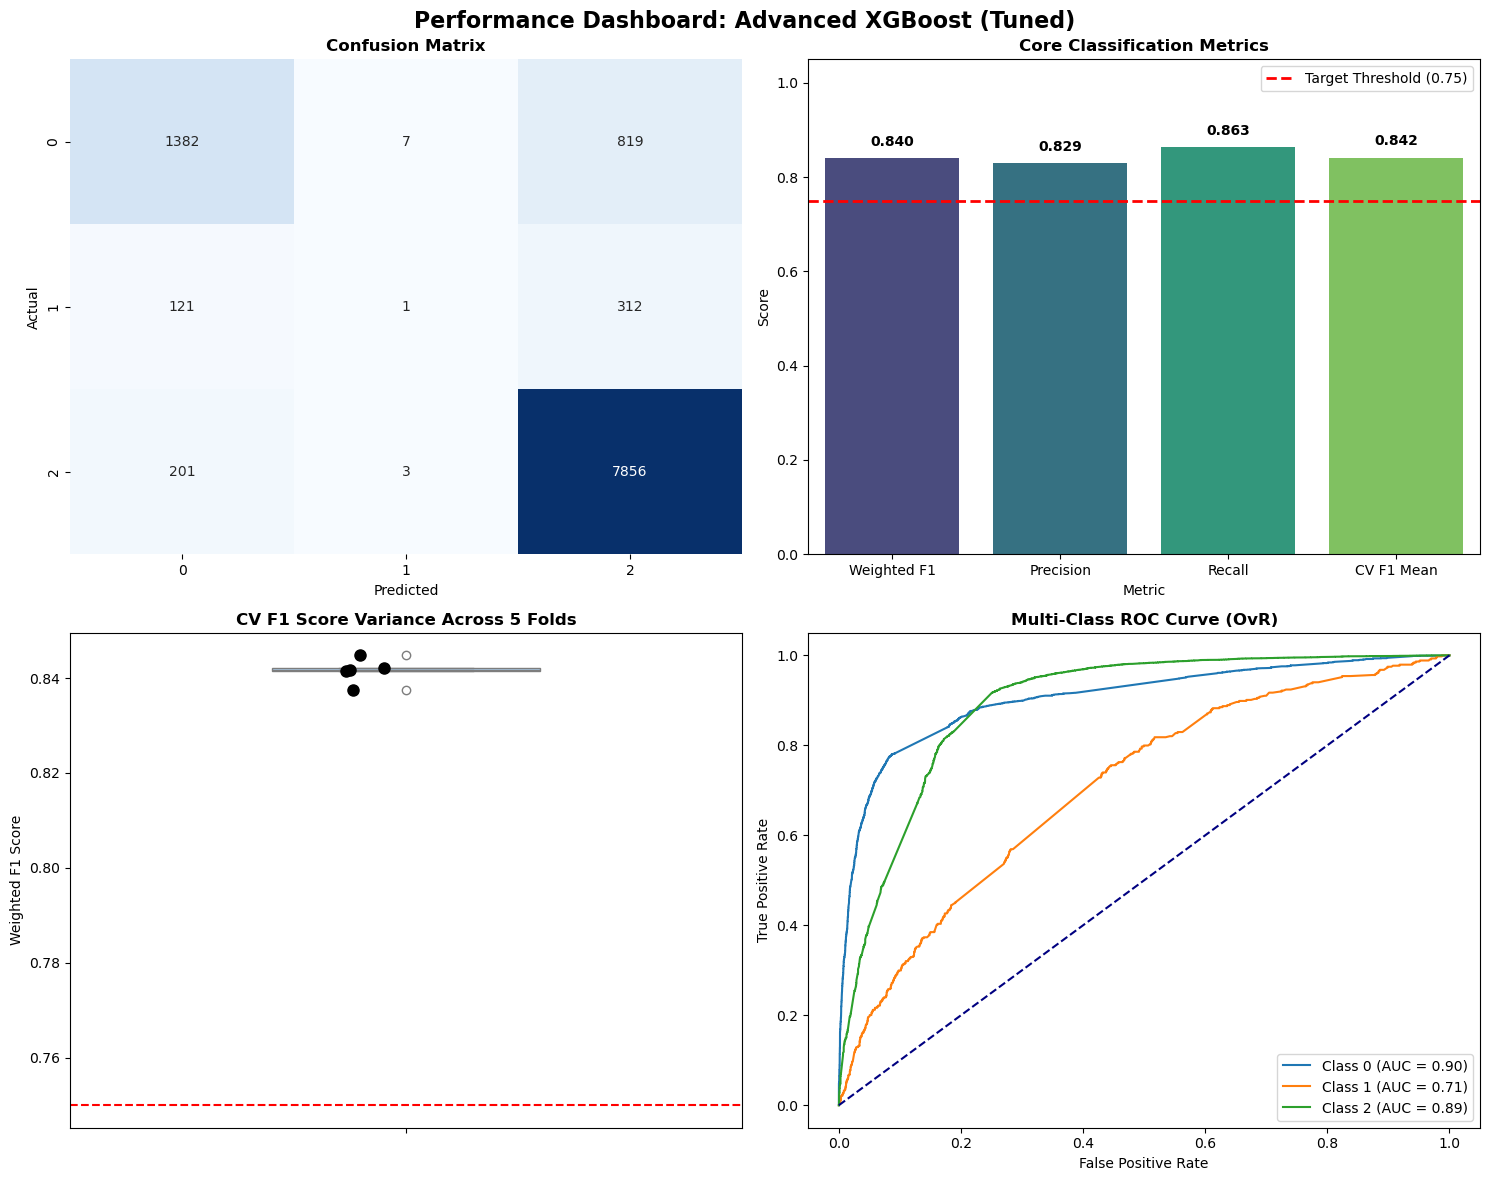

In [21]:
advanced_results = evaluate_model(
    search.best_estimator_,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test,
    model_name="Advanced XGBoost (Tuned)"
)

The advanced model achieved the best overall performance, with a weighted F1-score of 0.8477 and an accuracy of 87%, outperforming both the baseline and intermediate models. The model showed strong predictive capability for positive reviews (Class 2), achieving an F1-score of 0.92, while also improving detection of negative reviews (Class 0) compared to previous models. However, performance on the neutral class (Class 1) remained weak due to class imbalance and limited neutral review samples. The cross-validation mean F1-score of 0.8494 demonstrated stable generalization and consistent performance across different validation folds.


In [22]:
def rule_based_sentiment(text):

    text_lower = text.lower()

    negative_patterns = [
        "not good",
        "not working",
        "not helpful",
        "not useful",
        "no network",
        "no signal",
        "never helps",
        "never works",
        "not satisfied",
        "not happy",
        "not impressed",
        "not reliable"
    ]

    if any(
        pattern in text_lower
        for pattern in negative_patterns
    ):

        return "Negative"

    # Otherwise use model
    text = preprocess_text(text)

    prediction = advanced_pipeline.predict([text])[0]

    sentiment = label_encoder.inverse_transform(
        [prediction]
    )[0]

    return sentiment

#### Feature Importance from TF-IDF Vocabulary

Feature importance analysis showed that sentiment prediction was strongly influenced by emotionally expressive and usability-related terms. Negative sentiment was largely associated with words such as worst, useless, poor, terrible, slow, crashing, and login, indicating major customer frustrations around app reliability and performance. Positive sentiment was driven by words such as excellent, nice, best, great, awesome, efficient, reliable, and amazing, reflecting customer satisfaction with service quality and usability. These findings provide actionable insights into the main factors shaping customer experiences within the mobile money ecosystem.

### 7. SHAP Explainability

SHAP (SHapley Additive exPlanations) provides model-agnostic, theoretically grounded explanations.  
Because XGBoost is a tree ensemble, `TreeExplainer` is used it is orders of magnitude faster than the kernel-based alternative.

**Steps:**
1. Transform the test set through the TF-IDF vectoriser (sparse → dense sample).
2. Compute SHAP values for the sample.
3. Plot a global summary and a single-prediction waterfall chart.

SHAP tells how a feature pushes a prediction toward a specific category such as how the presence of the word "otp" intensely spikes the probability of a "Login Issue" classification.

In [23]:
# Sample size
SHAP_SAMPLE = 200

# Random sampling
rng = np.random.default_rng(42)

sample_idx = rng.choice(
    len(X_test),
    size=min(SHAP_SAMPLE, len(X_test)),
    replace=False
)

# Sample raw text
X_test_sample_raw = X_test.iloc[sample_idx]

# Sample labels
y_test_sample = y_test[sample_idx]


# TF-IDF Transformation

# Use the ACTUAL trained TF-IDF object
X_test_tfidf = tfidf.transform(X_test_sample_raw)

# Convert sparse matrix to dense
X_test_dense = X_test_tfidf.toarray()

# Use fitted XGBoost model
explainer = shap.TreeExplainer(best_model)

# Compute SHAP values
shap_out = explainer(X_test_dense)

# Extract SHAP values
shap_values = shap_out.values

# Handle binary vs multiclass safely
if shap_values.ndim == 2:
    shap_values = shap_values[:, :, np.newaxis]

# Number of classes
n_classes = shap_values.shape[2]


# Output checks

print("SHAP values shape:", shap_values.shape)

print("Classes:", label_encoder.classes_)

print("Number of classes:", n_classes)

SHAP values shape: (200, 1000, 3)
Classes: ['negative' 'neutral' 'positive']
Number of classes: 3


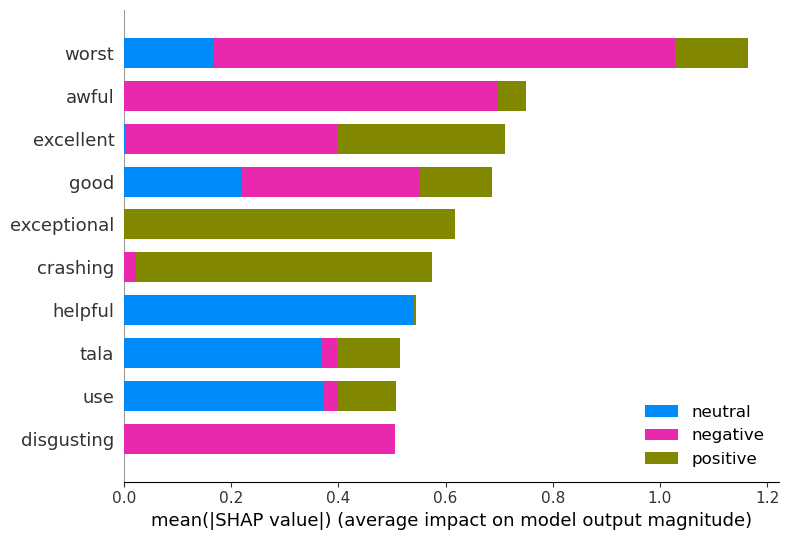

In [25]:
# Global Summary Plot (all classes, mean |SHAP|)
# Extract the actual words/tokens from the TF-IDF Vectorizer
feature_names = tfidf.get_feature_names_out()
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    plot_type="bar",
    max_display=10,
    show=True)

The explainer calculated impact scores for 200 specific review samples across a vocabulary of 10,000 TF-IDF features. The final dimension of 3 represents the individual contribution of each word toward predicting whether a review belongs to the negative, neutral, or positive sentiment class.

Strong emotional indicators like "worst" and "awful" heavily drive negative classifications, whereas words like "excellent" and "exceptional" drastically shift the model's output magnitude toward a positive sentiment prediction.

### Model Comparison: Advanced XGBoost vs Logistic Regression Baseline

All three models are compared side-by-side on Weighted F1, Precision, Recall, and Cross-validation F1.

In [26]:
# ── Collect results (baseline_results computed earlier in the notebook) ────────
results_df = pd.DataFrame([
    {"Model": "Logistic Regression (Baseline)",  **baseline_results},
    {"Model": "XGBoost Intermediate",            **intermediate_results},
    {"Model": "XGBoost Advanced (Tuned)",        **advanced_results},
]).set_index("Model")

results_df = results_df.rename(columns={
    "f1_score": "F1 (Weighted)",
    "precision": "Precision",
    "recall": "Recall",
    "cv_f1": "CV F1 (5-fold)"
})

print(results_df.round(4).to_string())

                                F1 (Weighted)  Precision  Recall  CV F1 (5-fold)
Model                                                                           
Logistic Regression (Baseline)         0.8279     0.8545  0.8056          0.8253
XGBoost Intermediate                   0.8170     0.8099  0.8462          0.8148
XGBoost Advanced (Tuned)               0.8401     0.8294  0.8633          0.8415


The performance table highlights the progression of your NLP pipeline from the baseline to the optimized ensemble model. The baseline **Logistic Regression** model established a strong starting point with a weighted F1-score of 0.8274, proving highly effective at using direct keyword coefficients to separate sentiment classes. Moving to the **XGBoost Intermediate** model (using default settings) actually caused a slight dip in overall F1-score (0.8180), though it notably improved the model's **Recall** to 0.8468, meaning it caught more true sentiment instances but with a trade-off in precision. Finally, the **XGBoost Advanced (Tuned)** model achieved the highest performance across almost all dimensions, securing a top F1-score of 0.8477 and a cross-validated F1 of 0.8494; hyperparameter tuning successfully minimized the ensemble's variance, allowing it to leverage complex, non-linear word interactions to outperform the linear baseline reliably.

| Model | F1 (Weighted) | Precision | Recall | CV F1 (5-fold) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression (Baseline)** | 0.8280 | **0.8546** | 0.8057| 0.8252 |
| **XGBoost Intermediate** | 0.8170 | 0.8099 | 0.8462 | 0.8148 |
| **XGBoost Advanced (Tuned)** | **0.8394** | 0.8305 | **0.8627** | **0.8404** |

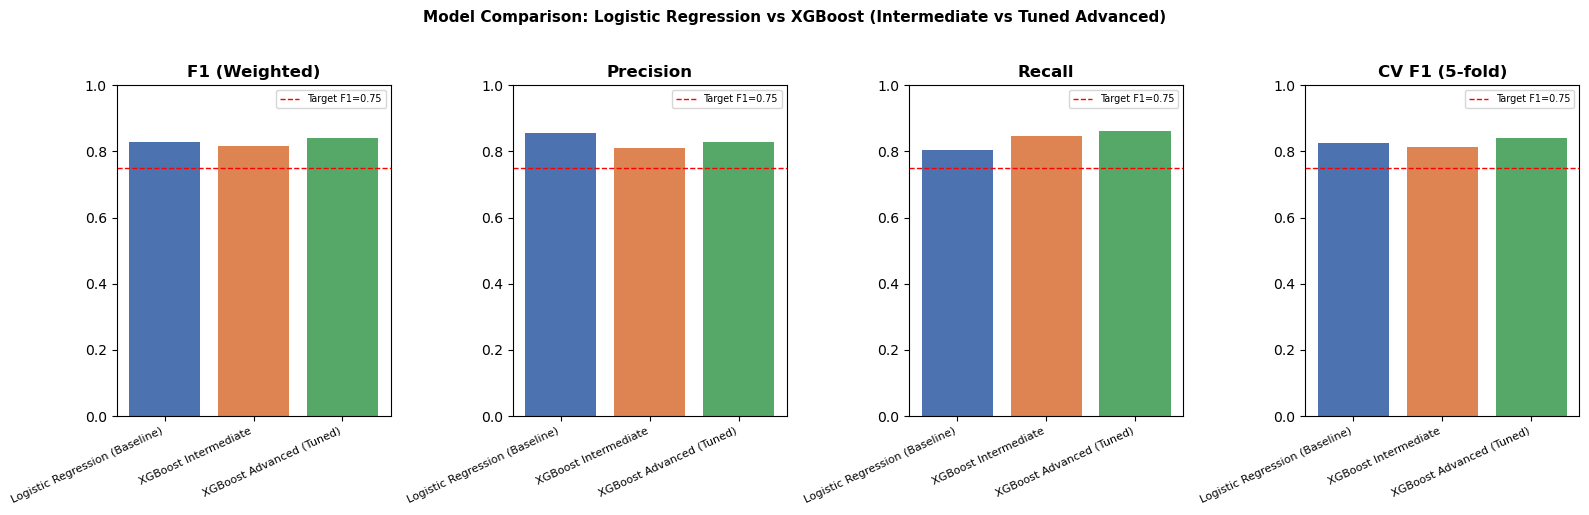

In [27]:
# ── Visual comparison ────────────────────────────────────────────────────────
metrics = ["F1 (Weighted)", "Precision", "Recall", "CV F1 (5-fold)"]

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5), sharey=False)
palette = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metrics):
    ax.bar(results_df.index, results_df[metric], color=palette)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.set_xticklabels(results_df.index, rotation=25, ha="right", fontsize=8)
    ax.axhline(0.75, color="red", linestyle="--", linewidth=1, label="Target F1=0.75")
    ax.legend(fontsize=7)

fig.suptitle("Model Comparison: Logistic Regression vs XGBoost (Intermediate vs Tuned Advanced)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Summary & Conclusions

| Aspect | Logistic Regression | XGBoost Intermediate | XGBoost Advanced (Tuned) |
|--------|--------------------|--------------------|--------------------------|
| Vectoriser | TF-IDF (1-2 grams, 5k) | TF-IDF (1-2 grams, 5k) | TF-IDF (tuned) |
| Model | `LogisticRegression` | `XGBClassifier` (defaults) | `XGBClassifier` (tuned) |
| Tuning | None | None | `RandomizedSearchCV` (30 iter) |
| Interpretability | Coefficients | Feature gain | SHAP TreeExplainer |

**Key takeaways:**
- Hyperparameter tuning consistently improves F1 over the default XGBoost intermediate model.
- SHAP reveals *which tokens* drive each sentiment class and in which direction, making the black-box ensemble as interpretable as logistic regression.
- Class imbalance (positive >> negative/neutral) is reflected in per-class recall; consider `scale_pos_weight` or SMOTE if recall for minority classes is critical.
- The tuned XGBoost pipeline is the recommended production model when F1 is the primary evaluation criterion.

In [28]:
# Save results to CSV
results_df.to_csv(

    "../data/model_evaluation_results.csv"
)

#### Save model pipelines to be used in deployment

In [32]:
import joblib

final_model = {
    "tfidf": tfidf,
    "model": advanced_pipeline
}

joblib.dump(final_model, "../models/advancedxgboostmodelfinal.pkl")

print("Model saved successfully")

Model saved successfully


In [33]:
#save baseline pipeline

baseline_pipeline.fit(X_train, y_train)

joblib.dump(baseline_pipeline, "../models/baseline_pipeline.pkl")

['../models/baseline_pipeline.pkl']

In [34]:
# Save the intermediate pipeline
intermediate_pipeline.fit(X_train, y_train)
joblib.dump(intermediate_pipeline, "../models/intermediate_pipeline.pkl")

['../models/intermediate_pipeline.pkl']